# Patient Readmission Risk Prediction
## 03 - XGBoost

This notebook trains an XGBoost classification model to predict
whether a patient will be readmitted within 30 days.

The target is binary classification:

1 = Readmitted within 30 days
0 = Not readmitted within 30 days

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

from xgboost import XGBClassifier

In [46]:
df = pd.read_csv("../data/processed/readmission_cleaned.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (101766, 112)


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady,change_No,diabetesMed_Yes
0,6,25,1,1,41,0,1,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1,1,1,7,3,59,0,18,0,0,0,...,1,1,0,0,0,0,0,0,0,1
2,1,1,7,2,11,5,13,2,0,1,...,0,1,0,0,0,0,0,0,1,1
3,1,1,7,2,44,1,16,0,0,0,...,1,1,0,0,0,0,0,0,0,1
4,1,1,7,1,51,0,8,0,0,0,...,0,1,0,0,0,0,0,0,0,1


In [47]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 101766
Columns: 112


In [48]:
print(df["readmitted_30_days"].value_counts())

readmitted_30_days
0    90409
1    11357
Name: count, dtype: int64


In [49]:
X = df.drop("readmitted_30_days", axis=1)
y = df["readmitted_30_days"]

X.columns = (
    X.columns
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
    .str.replace(">", "_", regex=False)
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (101766, 111)
y shape: (101766,)


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (81412, 111)
Testing data: (20354, 111)


In [51]:
print("Training class distribution:")
print(y_train.value_counts())

Training class distribution:
readmitted_30_days
0    72326
1     9086
Name: count, dtype: int64


In [52]:
scale_pos_weight = (
    (y_train == 0).sum()
    / (y_train == 1).sum()
)

print("Scale Pos Weight:", round(scale_pos_weight, 2))

Scale Pos Weight: 7.96


In [53]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


In [54]:
model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [55]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Prediction completed.")

Prediction completed.


In [56]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.6622


In [57]:
precision = precision_score(y_test, y_pred)

print("Precision:", round(precision, 4))

Precision: 0.185


In [58]:
recall = recall_score(y_test, y_pred)

print("Recall:", round(recall, 4))

Recall: 0.5953


In [59]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", round(f1, 4))

F1 Score: 0.2823


In [60]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.6875


In [61]:
print("XGBoost Model Performance")
print("--------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

XGBoost Model Performance
--------------------------
Accuracy : 0.6622
Precision: 0.185
Recall   : 0.5953
F1 Score : 0.2823
ROC-AUC  : 0.6875


In [62]:
print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "Not Readmitted",
        "Readmitted <30 Days"
    ]
))

                     precision    recall  f1-score   support

     Not Readmitted       0.93      0.67      0.78     18083
Readmitted <30 Days       0.19      0.60      0.28      2271

           accuracy                           0.66     20354
          macro avg       0.56      0.63      0.53     20354
       weighted avg       0.85      0.66      0.72     20354



In [63]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[12127  5956]
 [  919  1352]]


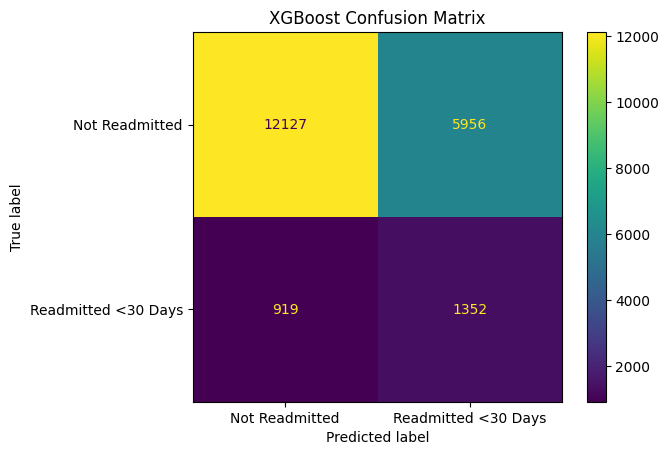

In [64]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Readmitted",
        "Readmitted <30 Days"
    ]
)

disp.plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

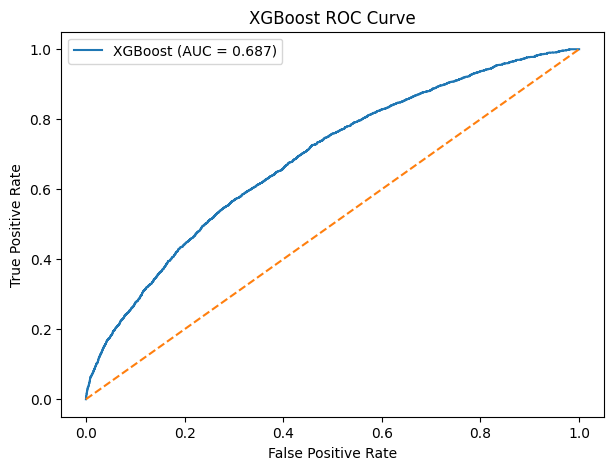

In [65]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()


In [66]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(20)

number_inpatient            0.078237
discharge_disposition_id    0.032456
total_previous_visits       0.020815
diabetesMed_Yes             0.014446
diag_2_Neoplasms            0.013150
diag_1_Unknown              0.012896
number_diagnoses            0.012731
diag_1_Respiratory          0.012535
number_emergency            0.012528
diag_1_Musculoskeletal      0.012215
repaglinide_Up              0.012054
age__50-60)                 0.011571
A1Cresult_None              0.011321
diag_1_Diabetes             0.011304
time_in_hospital            0.011087
rosiglitazone_Steady        0.011064
metformin_No                0.011015
metformin_Up                0.010901
insulin_No                  0.010873
glipizide_Steady            0.010686
dtype: float32

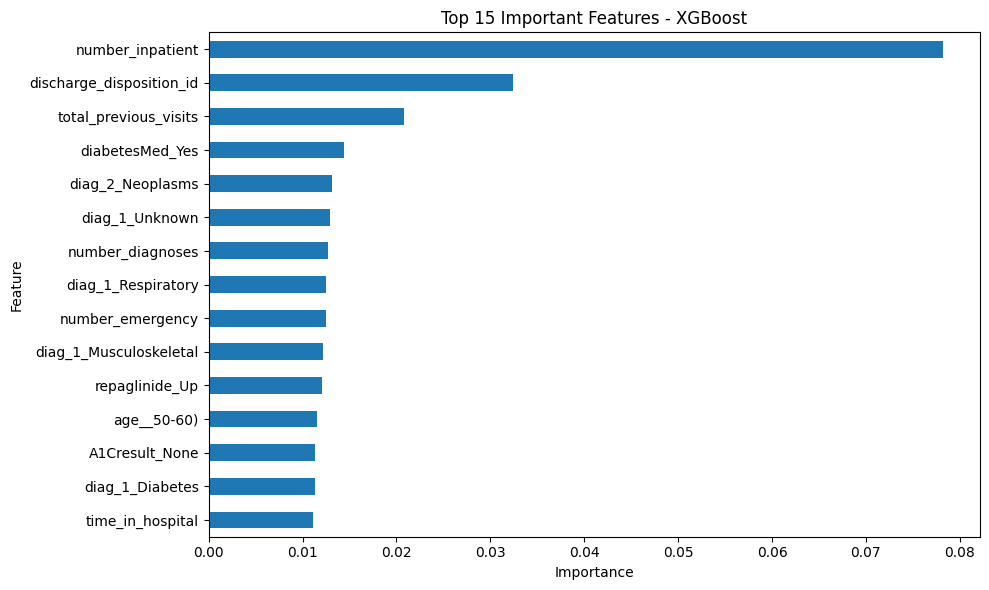

In [67]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

top_features.sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features - XGBoost")
plt.tight_layout()
plt.show()

In [68]:
print("Top 15 Important Features:")
print(top_features)

Top 15 Important Features:
number_inpatient            0.078237
discharge_disposition_id    0.032456
total_previous_visits       0.020815
diabetesMed_Yes             0.014446
diag_2_Neoplasms            0.013150
diag_1_Unknown              0.012896
number_diagnoses            0.012731
diag_1_Respiratory          0.012535
number_emergency            0.012528
diag_1_Musculoskeletal      0.012215
repaglinide_Up              0.012054
age__50-60)                 0.011571
A1Cresult_None              0.011321
diag_1_Diabetes             0.011304
time_in_hospital            0.011087
dtype: float32


In [69]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "XGBoost": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results["XGBoost"] = results["XGBoost"].round(4)

results

,Metric,XGBoost
0,Accuracy,0.6622
1,Precision,0.1850
2,Recall,0.5953
3,F1 Score,0.2823
4,ROC-AUC,0.6875


In [71]:
import joblib

joblib.dump(
    model,
    "../models/xgboost_model.pkl"
)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.
